In [4]:
from tadn_adapter import TADNAdapter, TADNConfig

In [5]:
import os
print(os.getcwd())
print("tadn_adapter.py" in os.listdir("."))

/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/TADN
True


In [6]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "input").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

print("Detected ROOT:", ROOT)

RAW_DEPTH_DIR = ROOT / "outputs"
TADN_DEPTH_DIR = ROOT / "outputs_tadn_v3"
TADN_DEPTH_DIR.mkdir(exist_ok=True)

print("RAW_DEPTH_DIR exists:", RAW_DEPTH_DIR.exists())
print("TADN_DEPTH_DIR:", TADN_DEPTH_DIR)

Detected ROOT: /


OSError: [Errno 30] Read-only file system: '/outputs_tadn_v3'

In [7]:
import cv2

depth_path = RAW_DEPTH_DIR / "t1_depth.png"
depth = cv2.imread(str(depth_path), cv2.IMREAD_GRAYSCALE)

if depth is None:
    raise FileNotFoundError(f"Could not load {depth_path}")

print("Loaded:", depth.shape, depth.dtype)

[ WARN:0@237.949] global loadsave.cpp:278 findDecoder imread_('/outputs/t1_depth.png'): can't open/read file: check file path/integrity


FileNotFoundError: Could not load /outputs/t1_depth.png

In [8]:
from tadn_adapter import TADNAdapter, TADNConfig

In [9]:
cfg = TADNConfig(
    clip_percentiles=(0.5, 99.5),
    use_bilateral=True,
    bilateral_d=11,
    bilateral_sigma_color=90,
    bilateral_sigma_space=90,
    use_clahe=True,
    clahe_clip_limit=2.5,
    clahe_tile_grid_size=(8, 8),
    use_edge_boost=True,
    edge_weight=0.35,
    sobel_ksize=3,
    edge_blur_ksize=5,
    use_gamma=True,
    gamma=0.85,
    out_size=None
)

adapter = TADNAdapter(cfg)
print("Adapter ready")

Adapter ready


In [10]:
from pathlib import Path

# Find project root robustly
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if p.name == "Thermal_Depth_Sandbox":
        ROOT = p
        break

if ROOT is None:
    raise RuntimeError("Thermal_Depth_Sandbox not found. Open the correct folder.")

RAW_DEPTH_DIR = ROOT / "outputs"
TADN_DIR = ROOT / "outputs_tadn_v3"
TADN_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("RAW_DEPTH_DIR:", RAW_DEPTH_DIR, RAW_DEPTH_DIR.exists())
print("TADN_DIR:", TADN_DIR, TADN_DIR.exists())

ROOT: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox
RAW_DEPTH_DIR: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs False
TADN_DIR: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs_tadn_v3 True


In [ ]:
from tadn_adapter import TADNAdapter, TADNConfig

cfg_safe = TADNConfig(
    clip_percentiles=(2.0, 98.0),

    use_bilateral=True,
    bilateral_d=7,
    bilateral_sigma_color=25.0,
    bilateral_sigma_space=25.0,

    use_clahe=False,         # OFF
    use_edge_boost=False,    # OFF
    use_gamma=True,
    gamma=1.0,

    out_size=(512, 512)
)

adapter_safe = TADNAdapter(cfg_safe)
print("adapter_safe defined")

adapter_safe defined ✅


In [12]:
import cv2

depth = cv2.imread(str(RAW_DEPTH_DIR / "t1_depth.png"), cv2.IMREAD_GRAYSCALE)
assert depth is not None, "Depth image not loaded"

depth_rgb_safe = adapter_safe(depth)

out_safe = TADN_DIR / "t1_depth_tadn_safe.png"
cv2.imwrite(str(out_safe), cv2.cvtColor(depth_rgb_safe, cv2.COLOR_RGB2BGR))

print("Saved:", out_safe)

[ WARN:0@250.773] global loadsave.cpp:278 findDecoder imread_('/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs/t1_depth.png'): can't open/read file: check file path/integrity


AssertionError: Depth image not loaded

In [13]:
import cv2
import numpy as np

print("1) Starting cell...")

in_path = RAW_DEPTH_DIR / "t1_depth.png"
print("2) Loading:", in_path)

depth = cv2.imread(str(in_path), cv2.IMREAD_GRAYSCALE)
print("3) depth is None?", depth is None)

if depth is None:
    raise FileNotFoundError(f"Could not load {in_path}")

print("4) depth shape/dtype:", depth.shape, depth.dtype, "min/max:", int(depth.min()), int(depth.max()))

print("5) Running adapter_safe...")
depth_rgb_safe = adapter_safe(depth)
print("6) adapter output shape/dtype:", depth_rgb_safe.shape, depth_rgb_safe.dtype, "min/max:", int(depth_rgb_safe.min()), int(depth_rgb_safe.max()))

out_safe = TADN_DIR / "t1_depth_tadn_safe.png"
print("7) Saving to:", out_safe)

ok = cv2.imwrite(str(out_safe), cv2.cvtColor(depth_rgb_safe, cv2.COLOR_RGB2BGR))
print("8) cv2.imwrite returned:", ok)

print("9) Done ")

1) Starting cell...
2) Loading: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs/t1_depth.png
3) depth is None? True


[ WARN:0@254.209] global loadsave.cpp:278 findDecoder imread_('/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs/t1_depth.png'): can't open/read file: check file path/integrity


FileNotFoundError: Could not load /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs/t1_depth.png

In [ ]:
from pathlib import Path

ROOT = Path("/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox")

RAW_DEPTH_DIR = ROOT / "depth outputs"      
TADN_DIR = ROOT / "outputs_tadn_v3"          

print("RAW_DEPTH_DIR:", RAW_DEPTH_DIR, "exists:", RAW_DEPTH_DIR.exists())
print("TADN_DIR:", TADN_DIR, "exists:", TADN_DIR.exists())

RAW_DEPTH_DIR: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/depth outputs exists: True
TADN_DIR: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs_tadn_v3 exists: True


In [ ]:
for i in range(1, 11):
    in_path = RAW_DEPTH_DIR / f"t{i}_depth.png"
    depth = cv2.imread(str(in_path), cv2.IMREAD_GRAYSCALE)
    if depth is None:
        raise FileNotFoundError(f"Missing: {in_path}")

    depth_rgb = adapter(depth)  

    out_path = TADN_DEPTH_DIR / f"t{i}_depth_tadn.png"
    cv2.imwrite(str(out_path), cv2.cvtColor(depth_rgb, cv2.COLOR_RGB2BGR))

    print("Saved:", out_path.name)

print("Done")

Saved: t1_depth_tadn.png
Saved: t2_depth_tadn.png
Saved: t3_depth_tadn.png
Saved: t4_depth_tadn.png
Saved: t5_depth_tadn.png
Saved: t6_depth_tadn.png
Saved: t7_depth_tadn.png
Saved: t8_depth_tadn.png
Saved: t9_depth_tadn.png
Saved: t10_depth_tadn.png
Done


In [ ]:
from pathlib import Path

ROOT = Path("/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox")
DEPTH_DIR = ROOT / "depth outputs"   

print("DEPTH_DIR exists?:", DEPTH_DIR.exists())
print("Files found:", len(list(DEPTH_DIR.glob("*"))))


for p in sorted(DEPTH_DIR.glob("*"))[:30]:
    print(p.name)

DEPTH_DIR exists?: True
Files found: 10
t10_depth.png
t1_depth.png
t2_depth.png
t3_depth.png
t4_depth.png
t5_depth.png
t6_depth.png
t7_depth.png
t8_depth.png
t9_depth.png


In [ ]:
import cv2
import numpy as np

from pathlib import Path

ROOT = Path("/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox")

RAW_DEPTH_DIR = ROOT / "depth outputs"
TADN_DIR      = ROOT / "outputs_tadn_v3"


for i in range(1, 11):
    in_path = RAW_DEPTH_DIR / f"t{i}_depth.png"
    print("1) Loading:", in_path)

    depth = cv2.imread(str(in_path), cv2.IMREAD_GRAYSCALE)

    if depth is None:
        print(f" Skipping t{i}: file not found/unreadable -> {in_path}")
        continue

    H, W = depth.shape[:2]
    print(f"2) input depth shape: {(H, W)} dtype={depth.dtype} min/max={int(depth.min())}/{int(depth.max())}")

    print("3) Running adapter_safe...")
    depth_rgb_safe = adapter_safe(depth)  

    if depth_rgb_safe is None:
        print(f"Skipping t{i}: adapter_safe returned None")
        continue

    
    if depth_rgb_safe.ndim == 2:
        
        depth_rgb_safe = cv2.cvtColor(depth_rgb_safe, cv2.COLOR_GRAY2RGB)

    outH, outW = depth_rgb_safe.shape[:2]
    if (outH, outW) != (H, W):
        print(f"adapter_safe resized output {(outH, outW)} -> resizing back to {(H, W)}")
        depth_rgb_safe = cv2.resize(depth_rgb_safe, (W, H), interpolation=cv2.INTER_NEAREST)

    
    if depth_rgb_safe.dtype != np.uint8:
        d = depth_rgb_safe.astype(np.float32)

        
        if d.ndim == 3:
            d = cv2.cvtColor(d, cv2.COLOR_RGB2GRAY)

        
        p1, p99 = np.percentile(d, (1, 99))
        d = np.clip(d, p1, p99)
        d = (d - p1) / (p99 - p1 + 1e-6)
        d = (d * 255).astype(np.uint8)

        depth_rgb_safe = cv2.cvtColor(d, cv2.COLOR_GRAY2RGB)

    print(f"4) output safe shape: {depth_rgb_safe.shape[:2]} dtype={depth_rgb_safe.dtype} "
          f"min/max={int(depth_rgb_safe.min())}/{int(depth_rgb_safe.max())}")

    out_safe = TADN_DIR / f"t{i}_depth_tadn_safe.png"
    print("5) Saving to:", out_safe)

    ok = cv2.imwrite(str(out_safe), cv2.cvtColor(depth_rgb_safe, cv2.COLOR_RGB2BGR))
    print("6) cv2.imwrite returned:", ok)

print("\nDone! Check:", TADN_DIR)


Processing t1...
1) Loading: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/depth outputs/t1_depth.png
2) input depth shape: (512, 640) dtype=uint8 min/max=2/255
3) Running adapter_safe...
⚠️ adapter_safe resized output (512, 512) -> resizing back to (512, 640)
4) output safe shape: (512, 640) dtype=uint8 min/max=0/255
5) Saving to: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs_tadn_v3/t1_depth_tadn_safe.png
6) cv2.imwrite returned: True

Processing t2...
1) Loading: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/depth outputs/t2_depth.png
2) input depth shape: (512, 640) dtype=uint8 min/max=2/255
3) Running adapter_safe...
⚠️ adapter_safe resized output (512, 512) -> resizing back to (512, 640)
4) output safe shape: (512, 640) dtype=uint8 min/max=0/255
5) Saving to: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/outputs_tadn_v3/t2_depth_tadn_safe.png
6) cv2.imwrite returned: True

Processing 

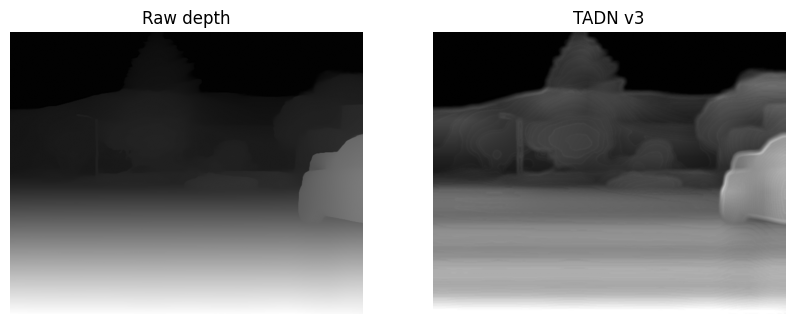

In [23]:
import matplotlib.pyplot as plt

raw = cv2.imread(str(RAW_DEPTH_DIR / "t1_depth.png"), cv2.IMREAD_GRAYSCALE)
tadn = cv2.imread(str(TADN_DEPTH_DIR / "t1_depth_tadn.png"), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Raw depth"); plt.imshow(raw, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("TADN v3"); plt.imshow(tadn, cmap="gray"); plt.axis("off")
plt.show()